In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import os

from scipy.stats import uniform, randint

from sklearn import set_config
from sklearn.model_selection import cross_val_score, GridSearchCV, RepeatedKFold, RandomizedSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Integer

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.util import Surv

# Gradient Boosting

## Preparing Data for Fitting

In [4]:
# load pre-processed datasets
train_data = pd.read_csv("../../datasets/csv_files/ml_datasets/train_data.csv")
test_data_one = pd.read_csv("../../datasets/csv_files/ml_datasets/test_data_one.csv")
test_data_two = pd.read_csv("../../datasets/csv_files/ml_datasets/test_data_two.csv")
test_data_three = pd.read_csv("../../datasets/csv_files/ml_datasets/test_data_three.csv")

In [5]:
# define X & y for all datasets
X_train = train_data[list(train_data.columns[3:])]
y_train = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', train_data)

X_test_one = test_data_one[list(test_data_one.columns[3:])]
X_test_one = X_test_one[X_train.columns]
y_test_one = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_one)

X_test_two = test_data_two[list(test_data_two.columns[3:])]
X_test_two = X_test_two[X_train.columns]
y_test_two = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_two)

X_test_three = test_data_three[list(test_data_three.columns[3:])]
X_test_three = X_test_three[X_train.columns]
y_test_three = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_three)

## Fit Initial Model

In [6]:
gbs_cox = GradientBoostingSurvivalAnalysis()
gbs_cox.fit(X_train, y_train)

,loss,'coxph'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,random_state,None


In [7]:
cross_val_score(gbs_cox, X_train, y_train, cv=5, n_jobs=-1).mean()

np.float64(0.6382278922257094)

## Tune Parameters for Better Fit
- max_depth
- learning_rate
- n_estimators
- min_samples_leaf
- subsample

In [8]:
param_distributions = {
    'max_depth': randint(1, 5),
    'learning_rate': uniform(0.001, 0.099),
    'n_estimators': randint(500, 3000),
    'min_samples_leaf': randint(5, 30),
    'subsample': uniform(0.5, 0.5),
    'max_features': uniform(0.3, 0.7),
}
cv_strategy = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

In [9]:
# gbs_cox_grid = GridSearchCV(
#     gbs_cox, param_distributions, cv=cv_strategy,
#     scoring=None,
#     n_jobs=-1, verbose=3
# )
# gbs_cox_grid.fit(X_train, y_train)

In [10]:
gbs_cox_random = RandomizedSearchCV(
    gbs_cox, param_distributions, n_iter=50,
    cv=cv_strategy, n_jobs=-1, random_state=42, verbose=3
)
gbs_cox_random.fit(X_train, y_train)

Fitting 15 folds for each of 50 candidates, totalling 750 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ivalAnalysis()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....00175057AC8D0>, 'max_depth': <scipy.stats....00175009E3F90>, 'max_features': <scipy.stats....0017500DC13D0>, 'min_samples_leaf': <scipy.stats....0017500DC3A10>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` fo

In [11]:
# print("Bayes Search Best Parameters:", gbs_cox_grid.best_params_)
# print("Bayes Search Best Score:", gbs_cox_grid.best_score_)
print("Random Search Best Parameters:", gbs_cox_random.best_params_)
print("Random Search Best Score:", gbs_cox_random.best_score_)

Random Search Best Parameters: {'learning_rate': np.float64(0.002580658969801205), 'max_depth': 2, 'max_features': np.float64(0.7789631185585097), 'min_samples_leaf': 19, 'n_estimators': 1978, 'subsample': np.float64(0.8049983288913105)}
Random Search Best Score: 0.6754698218543674


## Train & Test with Early Stopping

In [12]:
class EarlyStoppingMonitor:
    def __init__(self, window_size, max_iter_without_improvement):
        self.window_size = window_size
        self.max_iter_without_improvement = max_iter_without_improvement
        self._best_step = -1

    def __call__(self, iteration, estimator, args):
        # continue training for first self.window_size iterations
        if iteration < self.window_size:
            return False

        # compute average improvement in last self.window_size iterations.
        # oob_improvement_ is the different in negative log partial likelihood
        # between the previous and current iteration
        start = iteration - self.window_size + 1
        end = iteration + 1
        improvement = np.mean(estimator.oob_improvement_[start:end])

        if improvement > 1e-6:
            self._best_step = iteration
            return False  # continue fitting

        # stop fitting if there was no improvement
        # in last max_iter_without_improvement iterations
        diff = iteration - self._best_step
        return diff >= self.max_iter_without_improvement

In [13]:
monitor = EarlyStoppingMonitor(20,10)
# gbs_cox_grid_early = GradientBoostingSurvivalAnalysis(**gbs_cox_grid.best_params_, random_state=42)
# gbs_cox_grid_early.fit(X_train, y_train, monitor=monitor)

# cindex_one = gbs_cox_grid_early.score(X_test_one, y_test_one)
# cindex_two = gbs_cox_grid_early.score(X_test_two, y_test_two)
# cindex_three = gbs_cox_grid_early.score(X_test_three, y_test_three)

# print("Bayes Search Results:\n")
# print("Fitted base learners:", gbs_cox_grid_early.n_estimators_)
# print("Performance on test set 1:", round(cindex_one, 3))
# print("Performance on test set 2:", round(cindex_two, 3))
# print("Performance on test set 3:", round(cindex_three, 3))

In [14]:
gbs_cox_random_early = GradientBoostingSurvivalAnalysis(**gbs_cox_random.best_params_, random_state=42)
gbs_cox_random_early.fit(X_train, y_train, monitor=monitor)

cindex_one = gbs_cox_random_early.score(X_test_one, y_test_one)
cindex_two = gbs_cox_random_early.score(X_test_two, y_test_two)
cindex_three = gbs_cox_random_early.score(X_test_three, y_test_three)

print("Random Search Results:\n")
print("Fitted base learners:", gbs_cox_random_early.n_estimators_)
print("Performance on test set 1:", round(cindex_one, 3))
print("Performance on test set 2:", round(cindex_two, 3))
print("Performance on test set 3:", round(cindex_three, 3))

Random Search Results:

Fitted base learners: 21
Performance on test set 1: 0.613
Performance on test set 2: 0.474
Performance on test set 3: 0.61


## Permutation Importance

In [15]:
from sklearn.inspection import permutation_importance

perm_path = "../../models/gb_perm_importance.csv"

if os.path.exists(perm_path):
    print("Loading cached permutation importance...")
    perm_df = pd.read_csv(perm_path)
else:
    print("Computing permutation importance (n_repeats=5 — may take several minutes)...")
    result = permutation_importance(
        gbs_cox_random_early, X_train, y_train,
        n_repeats=5, random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame({
        "gene":            X_train.columns,
        "importance_mean": result.importances_mean,
        "importance_std":  result.importances_std,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    perm_df.to_csv(perm_path, index=False)
    print("Done. Cached to gb_perm_importance.csv")

print(f"\nTop 20 features by permutation importance:")
print(perm_df.head(20).to_string(index=False))

Loading cached permutation importance...

Top 20 features by permutation importance:
   gene  importance_mean  importance_std
  CDC20         0.027097        0.007380
   PLK2         0.008830        0.002449
   PYGL         0.006236        0.002934
    EVL         0.004857        0.003826
   SOX4         0.004581        0.002069
  FBXL5         0.004249        0.004220
   MICB         0.003311        0.001117
    JUP         0.003146        0.001679
  CEBPA         0.002373        0.001278
  KLHL5         0.002208        0.001374
RPS6KA1         0.001325        0.001176
  CEBPD         0.001325        0.000707
  S100P         0.001325        0.001081
 MAPK10         0.001159        0.000535
   APOB         0.001159        0.000442
 LILRB5         0.000938        0.000221
   SVIP         0.000883        0.000475
  MMP28         0.000828        0.000427
   LGMN         0.000773        0.000563
  MGST1         0.000717        0.000900


Saved: gb_permutation_importance.png


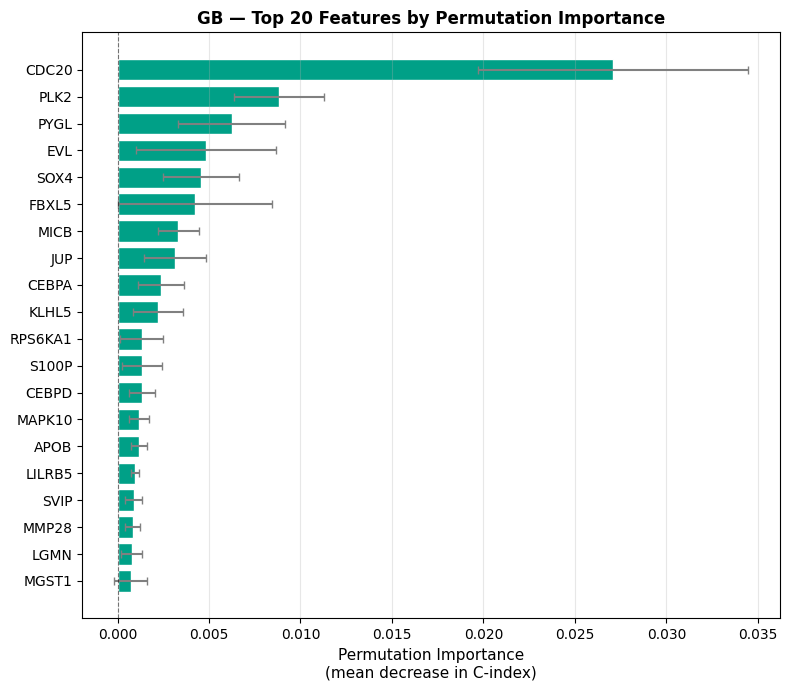

In [16]:
# Bar chart: top 20 genes by permutation importance
top20 = perm_df.head(20).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20["gene"], top20["importance_mean"],
        xerr=top20["importance_std"], color="#00A087",
        error_kw=dict(ecolor="grey", capsize=3), edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Permutation Importance\n(mean decrease in C-index)", fontsize=11)
ax.set_title("GB — Top 20 Features by Permutation Importance", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../../visuals/gb_permutation_importance.png", dpi=150, bbox_inches="tight")
print("Saved: gb_permutation_importance.png")
plt.show()

## GB Gene Signature

In [17]:
from scipy.stats import spearmanr

# Aggressive / compact signature: top 8 genes with positive permutation importance
sig_df = perm_df[perm_df["importance_mean"] > 0].head(8).copy()
if len(sig_df) < 3:
    sig_df = perm_df.head(8).copy()

sig_genes = sig_df["gene"].tolist()

# Risk score: predicted cumulative hazard (higher = higher relapse risk)
gb_risk_train = gbs_cox_random_early.predict(X_train)

directions = []
for gene in sig_genes:
    r, p = spearmanr(X_train[gene], gb_risk_train)
    directions.append({
        "gene":       gene,
        "importance": round(sig_df.loc[sig_df["gene"] == gene, "importance_mean"].values[0], 5),
        "spearman_r": round(r, 4),
        "p_value":    round(p, 4),
        "role":       "danger" if r > 0 else "protective",
    })

sig_genes_df = pd.DataFrame(directions)

# Paper comparison
PAPER_SIGNATURE = ["TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1"]
in_paper  = [g for g in sig_genes if g in PAPER_SIGNATURE]
not_paper = [g for g in sig_genes if g not in PAPER_SIGNATURE]
missing   = [g for g in PAPER_SIGNATURE if g not in sig_genes]

print("=" * 55)
print(f"  GB IMMUNE RISK SIGNATURE  ({len(sig_genes)} genes)")
print("=" * 55)
for _, row in sig_genes_df.iterrows():
    marker = "  [paper]" if row["gene"] in PAPER_SIGNATURE else ""
    print(f"  {row['gene']:<12}  imp={row['importance']:.5f}  r={row['spearman_r']:+.3f}  {row['role']}{marker}")

print()
print(f"Paper overlap : {len(in_paper)}/{len(PAPER_SIGNATURE)} — {in_paper}")
print(f"Novel genes   : {not_paper}")
print(f"Paper genes missing: {missing}")

  GB IMMUNE RISK SIGNATURE  (8 genes)
  CDC20         imp=0.02710  r=+0.546  danger
  PLK2          imp=0.00883  r=-0.196  protective
  PYGL          imp=0.00624  r=-0.124  protective
  EVL           imp=0.00486  r=-0.702  protective
  SOX4          imp=0.00458  r=+0.336  danger
  FBXL5         imp=0.00425  r=-0.591  protective
  MICB          imp=0.00331  r=-0.182  protective
  JUP           imp=0.00315  r=+0.062  danger

Paper overlap : 0/8 — []
Novel genes   : ['CDC20', 'PLK2', 'PYGL', 'EVL', 'SOX4', 'FBXL5', 'MICB', 'JUP']
Paper genes missing: ['TSLP', 'BIRC5', 'S100B', 'MDK', 'S100P', 'RARRES3', 'BLNK', 'ACO1']


## Risk Score & Patient Stratification

In [18]:
gb_risk_test_one   = gbs_cox_random_early.predict(X_test_one)
gb_risk_test_two   = gbs_cox_random_early.predict(X_test_two)
gb_risk_test_three = gbs_cox_random_early.predict(X_test_three)

print("Risk score summaries (GB cumulative hazard):")
for name, scores in [("Train",  gb_risk_train),
                     ("Test 1", gb_risk_test_one),
                     ("Test 2", gb_risk_test_two),
                     ("Test 3", gb_risk_test_three)]:
    print(f"  {name:8s} — n={len(scores):3d}  mean={scores.mean():.3f}  "
          f"median={np.median(scores):.3f}  min={scores.min():.3f}  max={scores.max():.3f}")

Risk score summaries (GB cumulative hazard):
  Train    — n=104  mean=-0.000  median=-0.003  min=-0.022  max=0.027
  Test 1   — n=244  mean=-0.004  median=-0.011  min=-0.020  max=0.025
  Test 2   — n= 88  mean=-0.003  median=-0.011  min=-0.018  max=0.024
  Test 3   — n=117  mean=-0.014  median=-0.014  min=-0.018  max=0.010


Training median risk score (cutoff): -0.0031
Train    — high= 52  low= 52  log-rank p=0.0000
Test 1   — high= 99  low=145  log-rank p=0.0092
Test 2   — high= 30  low= 58  log-rank p=0.0944
Test 3   — high=  4  low=113  log-rank p=0.2010

Saved: gb_km_stratification.png


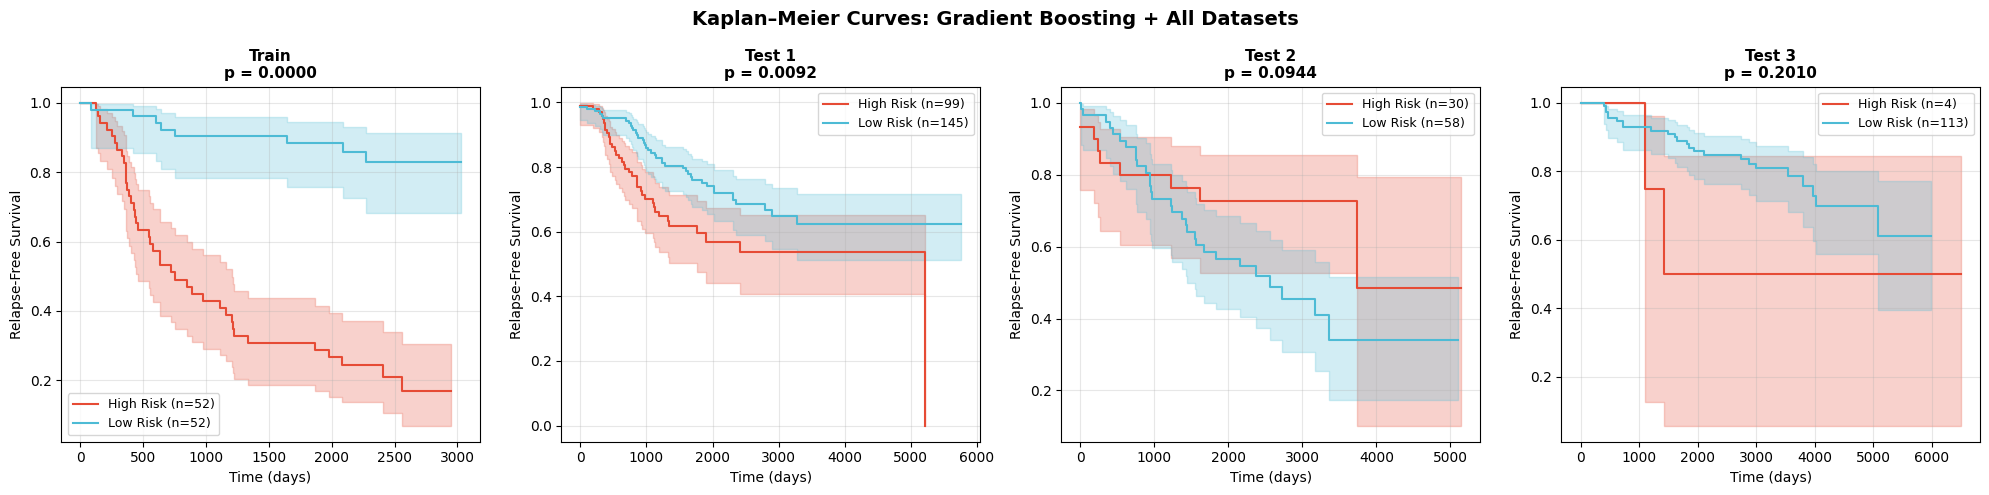

In [19]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Cutoff: median of training risk scores
train_median = np.median(gb_risk_train)
print(f"Training median risk score (cutoff): {train_median:.4f}")

def stratify(scores):
    return np.where(scores >= train_median, "High Risk", "Low Risk")

def plot_km(df, scores, title, ax):
    groups = stratify(scores)
    tmp = pd.DataFrame({
        "time":  pd.to_numeric(df["relapse_free_time"],  errors="coerce").astype(float),
        "event": pd.to_numeric(df["relapse_free_event"], errors="coerce").astype(bool),
        "group": groups,
    }).dropna(subset=["time", "event"])

    kmf = KaplanMeierFitter()
    colors = {"High Risk": "#E64B35", "Low Risk": "#4DBBD5"}
    for group, color in colors.items():
        mask = tmp["group"] == group
        if mask.sum() == 0:
            continue
        kmf.fit(tmp.loc[mask, "time"], tmp.loc[mask, "event"],
                label=f"{group} (n={mask.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

    high = tmp["group"] == "High Risk"
    low  = tmp["group"] == "Low Risk"
    p = logrank_test(tmp.loc[high, "time"], tmp.loc[low, "time"],
                     tmp.loc[high, "event"], tmp.loc[low, "event"]).p_value

    ax.set_title(f"{title}\np = {p:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Relapse-Free Survival")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    return p

gb_groups_train = stratify(gb_risk_train)

datasets = [
    ("Train",  train_data,      gb_risk_train),
    ("Test 1", test_data_one,   gb_risk_test_one),
    ("Test 2", test_data_two,   gb_risk_test_two),
    ("Test 3", test_data_three, gb_risk_test_three),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, df, scores) in zip(axes, datasets):
    groups = stratify(scores)
    p = plot_km(df, scores, name, ax)
    print(f"{name:8s} — high={np.sum(groups=='High Risk'):3d}  "
          f"low={np.sum(groups=='Low Risk'):3d}  log-rank p={p:.4f}")
    
plt.suptitle("Kaplan–Meier Curves: Gradient Boosting + All Datasets", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../../visuals/gb_km_stratification.png", dpi=150, bbox_inches="tight")
print("\nSaved: gb_km_stratification.png")
plt.show()

## Gene Signature Visualizations

Saved: gb_gene_signature_heatmap.png


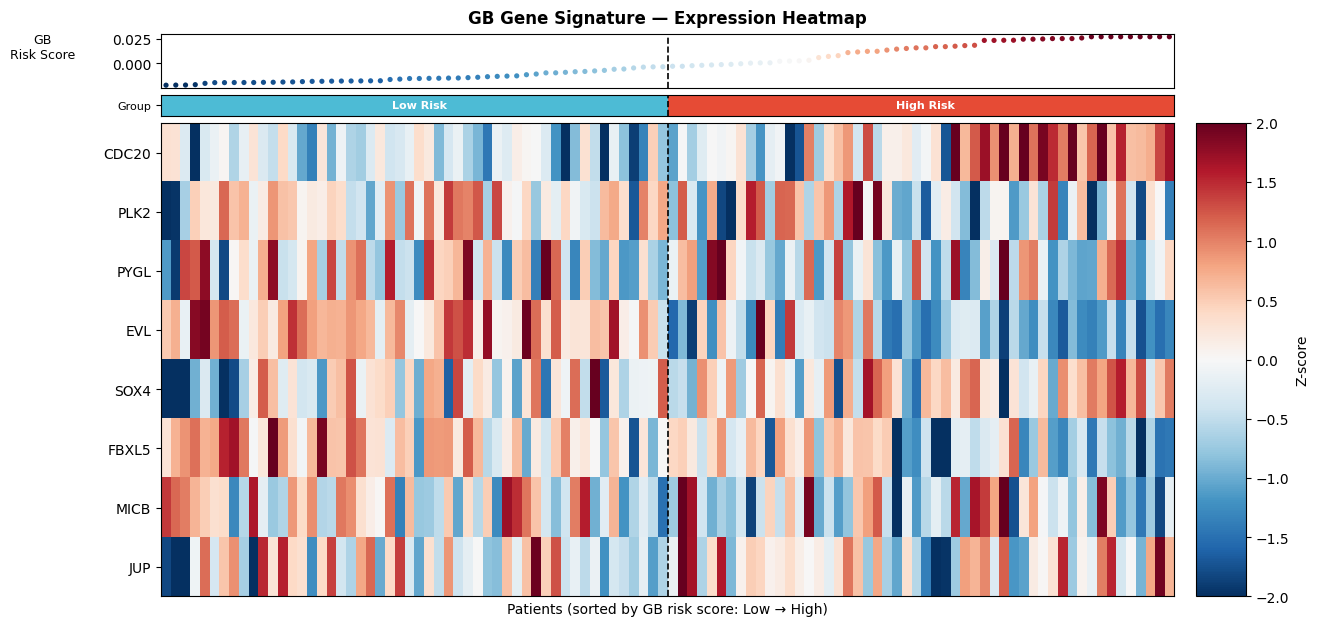

In [20]:
from scipy.stats import zscore
from matplotlib.colors import ListedColormap

# Sort patients by GB risk score (low → high)
sort_idx      = np.argsort(gb_risk_train)
sorted_scores = gb_risk_train[sort_idx]
sorted_groups = gb_groups_train[sort_idx]

expr_mat   = train_data[sig_genes].values[sort_idx].T    # (n_genes, n_patients)
expr_z     = zscore(expr_mat, axis=1)
n_patients = expr_mat.shape[1]
split      = int(np.sum(sorted_groups == "Low Risk"))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 2.5 + len(sig_genes) * 0.6))
gs  = fig.add_gridspec(3, 2,
                       height_ratios=[0.9, 0.35, len(sig_genes)],
                       width_ratios=[20, 1],
                       hspace=0.04, wspace=0.04)

ax_rs = fig.add_subplot(gs[0, 0])
ax_rs.scatter(range(n_patients), sorted_scores,
              c=sorted_scores, cmap="RdBu_r", s=14, linewidths=0)
ax_rs.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_rs.set_ylabel("GB\nRisk Score", fontsize=9, rotation=0, labelpad=50)
ax_rs.set_xlim(-0.5, n_patients - 0.5)
ax_rs.set_xticks([])
ax_rs.set_title("GB Gene Signature — Expression Heatmap", fontsize=12, fontweight="bold", pad=8)

ax_grp = fig.add_subplot(gs[1, 0], sharex=ax_rs)
ax_grp.imshow(np.where(sorted_groups == "High Risk", 1, 0).reshape(1, -1),
              aspect="auto", cmap=ListedColormap(["#4DBBD5", "#E64B35"]), vmin=0, vmax=1)
ax_grp.set_yticks([0])
ax_grp.set_yticklabels(["Group"], fontsize=8)
ax_grp.set_xticks([])
ax_grp.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_grp.text(split / 2, 0, "Low Risk",  ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax_grp.text(split + (n_patients - split) / 2, 0, "High Risk", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax_hm = fig.add_subplot(gs[2, 0], sharex=ax_rs)
im = ax_hm.imshow(expr_z, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax_hm.set_yticks(range(len(sig_genes)))
ax_hm.set_yticklabels(sig_genes, fontsize=10)
ax_hm.set_xlabel("Patients (sorted by GB risk score: Low → High)", fontsize=10)
ax_hm.axvline(split - 0.5, color="black", lw=1.2, ls="--")

plt.colorbar(im, cax=fig.add_subplot(gs[2, 1]), label="Z-score")
plt.savefig("../../visuals/gb_gene_signature_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: gb_gene_signature_heatmap.png")
plt.show()

Saved: gb_gene_signature_expression.png


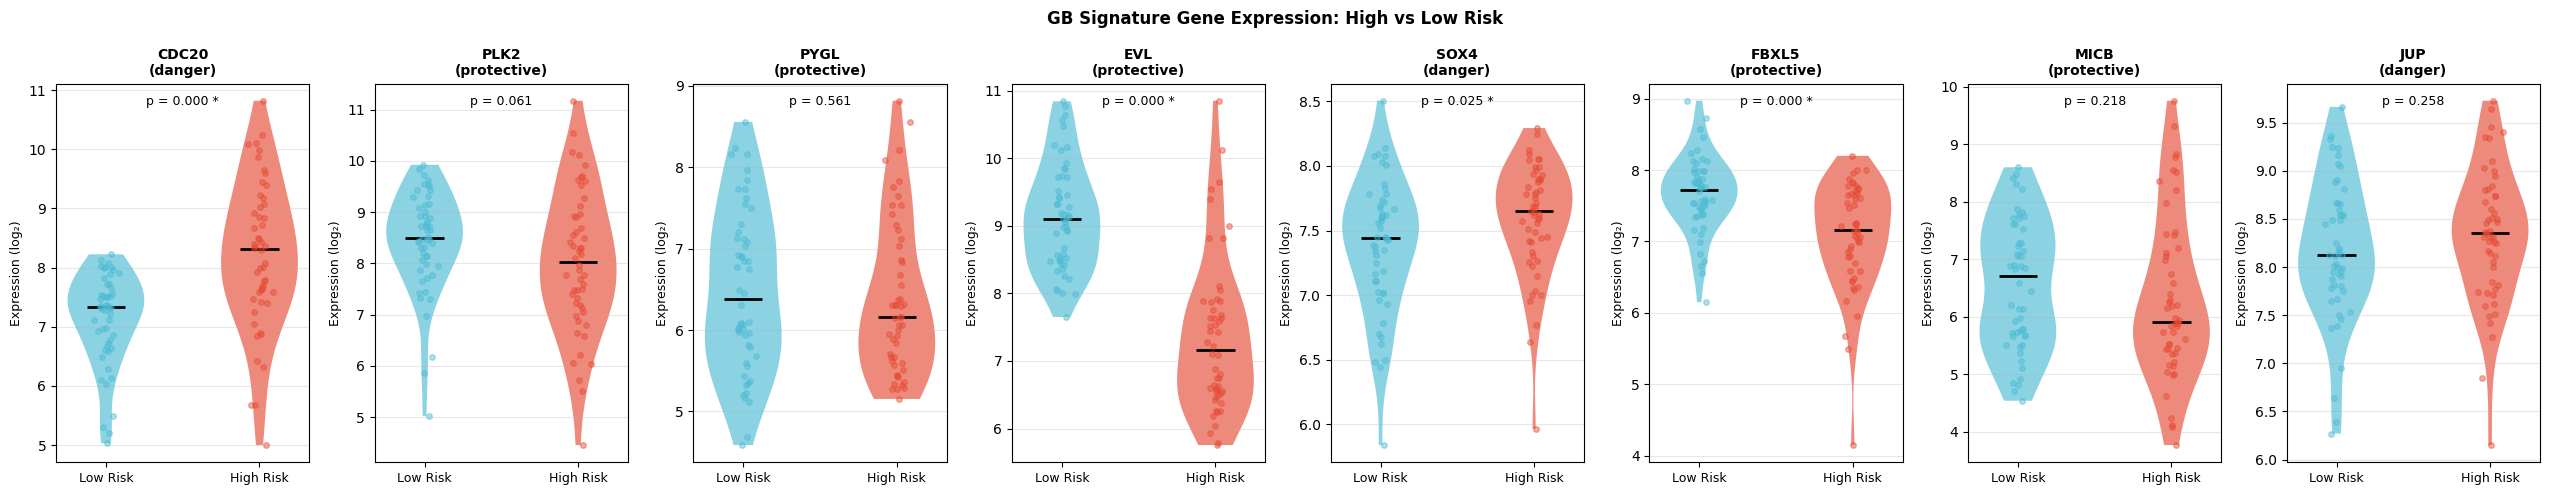

In [21]:
from scipy.stats import mannwhitneyu

mask_low  = (gb_groups_train == "Low Risk")
mask_high = (gb_groups_train == "High Risk")

n_genes = len(sig_genes)
fig, axes = plt.subplots(1, n_genes, figsize=(max(6, 3.2 * n_genes), 5))
if n_genes == 1:
    axes = [axes]

for ax, gene in zip(axes, sig_genes):
    data_low  = train_data[gene].values[mask_low]
    data_high = train_data[gene].values[mask_high]

    if len(data_low) < 2 or len(data_high) < 2:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                transform=ax.transAxes, fontsize=9)
        ax.set_title(gene, fontsize=10, fontweight="bold")
        continue

    parts = ax.violinplot([data_low, data_high], positions=[0, 1],
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], ["#4DBBD5", "#E64B35"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    for pos, data, color in [(0, data_low, "#4DBBD5"), (1, data_high, "#E64B35")]:
        jitter = np.random.default_rng(42).normal(0, 0.04, len(data))
        ax.scatter(pos + jitter, data, alpha=0.45, s=16, color=color, zorder=3)

    _, p = mannwhitneyu(data_low, data_high, alternative="two-sided")
    role = sig_genes_df.loc[sig_genes_df["gene"] == gene, "role"].values[0]
    ax.text(0.5, 0.97, f"p = {p:.3f}" + (" *" if p < 0.05 else ""),
            transform=ax.transAxes, ha="center", va="top", fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low Risk", "High Risk"], fontsize=9)
    ax.set_title(f"{gene}\n({role})", fontsize=10, fontweight="bold")
    ax.set_ylabel("Expression (log₂)", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("GB Signature Gene Expression: High vs Low Risk", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../visuals/gb_gene_signature_expression.png", dpi=150, bbox_inches="tight")
print("Saved: gb_gene_signature_expression.png")
plt.show()

Saved: gb_gene_signature_correlation.png


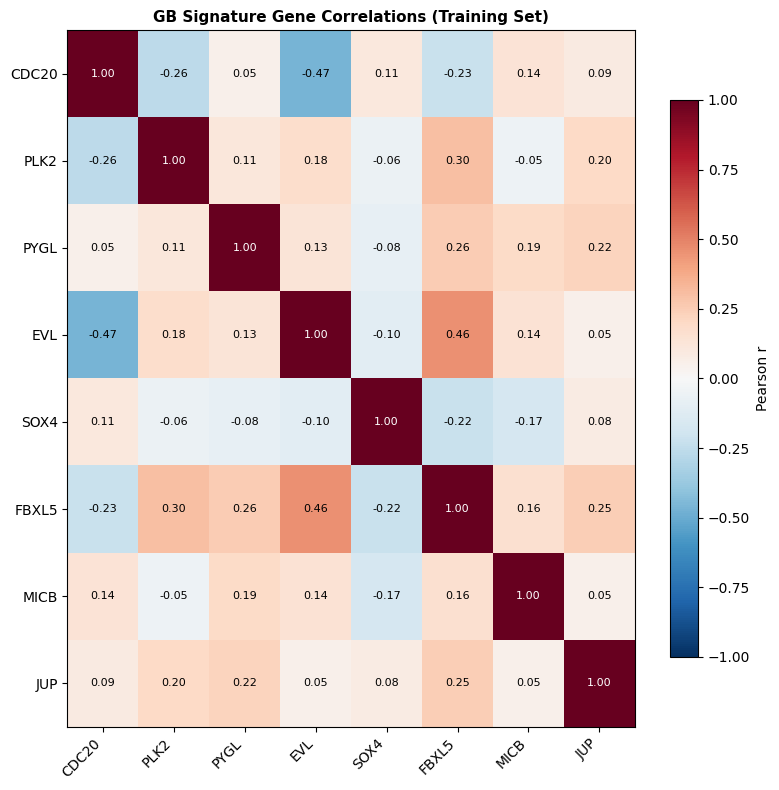

In [22]:
# ── Correlation heatmap between sig genes ─────────────────────────────────────
if len(sig_genes) > 1:
    corr = train_data[sig_genes].corr(method="pearson")

    fig, ax = plt.subplots(figsize=(max(4, len(sig_genes)), max(3.5, len(sig_genes))))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(sig_genes)))
    ax.set_yticks(range(len(sig_genes)))
    ax.set_xticklabels(sig_genes, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(sig_genes, fontsize=10)

    for i in range(len(sig_genes)):
        for j in range(len(sig_genes)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 0.6 else "black")

    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
    ax.set_title("GB Signature Gene Correlations (Training Set)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../../visuals/gb_gene_signature_correlation.png", dpi=150, bbox_inches="tight")
    print("Saved: gb_gene_signature_correlation.png")
    plt.show()
else:
    print("Only 1 significant gene — correlation heatmap skipped.")

## Save Model

In [23]:
os.makedirs("../../models", exist_ok=True)
joblib.dump(gbs_cox_random_early, "../../models/gbs_cox.joblib")

['../../models/gbs_cox.joblib']